In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, BatchNormalization, Dropout

In [2]:
training_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/drive/MyDrive/Cats-vs-Dogs/dogs_cats_sample_1000/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/drive/MyDrive/Cats-vs-Dogs/dogs_cats_sample_1000/valid',
    labels = 'inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 2000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [3]:
def process(image, label):
  image = tf.cast(image/255. , tf.float32)
  return image,label

training_ds = training_ds.map(process)
validation_ds = validation_ds.map(process)

In [19]:
model = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(256,256,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     7,372,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,466,177 (28.48 MB)

 Trainable params: 7,466,177 (28.48 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer='adam',
              loss = 'binary_crossentropy',
              metrics=['accuracy']
)

In [21]:
history = model.fit(training_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 281ms/step - accuracy: 0.5267 - loss: 1.0198 - val_accuracy: 0.5480 - val_loss: 0.6828
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.6104 - loss: 0.6410 - val_accuracy: 0.6180 - val_loss: 0.6350
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.7018 - loss: 0.5767 - val_accuracy: 0.6560 - val_loss: 0.6346
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.7564 - loss: 0.5175 - val_accuracy: 0.7030 - val_loss: 0.6052
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.8094 - loss: 0.4015 - val_accuracy: 0.6995 - val_loss: 0.6485
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.8677 - loss: 0.2918 - val_accuracy: 0.6890 - val_loss: 0.8891
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.9040 - loss: 0.2205 - val_accuracy: 0.6825 - val_loss: 0.9451
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - accuracy: 0.9433 - loss: 0.1516 - val_accu

In [22]:
model.evaluate(validation_ds)

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.6809 - loss: 1.5634


[1.5357136726379395, 0.690500020980835]

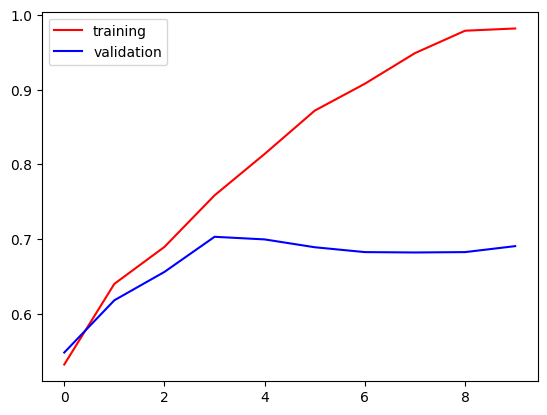

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='training')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

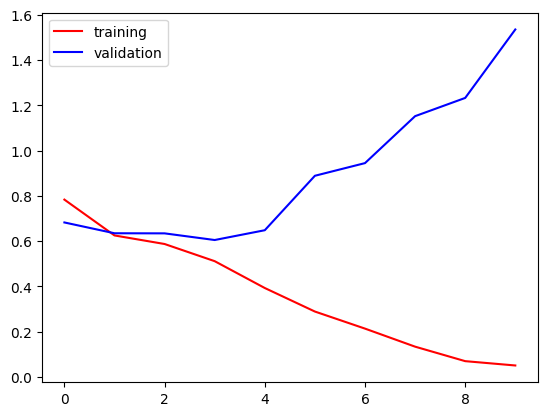

In [25]:
plt.plot(history.history['loss'], color='red', label='training')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()